# **Mirza Naeem Beg** <br>Id: 20210204033 <br>Section: A2
# Experiment 1: Minimum Error Rate Classifier

This notebook implements a minimum error rate classifier for a two-class problem, as described in the assignment question. We assume the data for each class follows a multivariate normal distribution.

### Problem Definition

We have two classes, $\omega_1$ and $\omega_2$, with the following properties:

**Class 1 ($\omega_1$):**
- Prior Probability: $P(\omega_1) = 0.5$
- Mean Vector: $\mu_1 = [0, 0]^T$
- Covariance Matrix: $\Sigma_1 = \begin{bmatrix} 0.25 & 0.3 \\ 0.3 & 1 \end{bmatrix}$

**Class 2 ($\omega_2$):**
- Prior Probability: $P(\omega_2) = 0.5$
- Mean Vector: $\mu_2 = [2, 2]^T$
- Covariance Matrix: $\Sigma_2 = \begin{bmatrix} 0.5 & 0 \\ 0 & 0.5 \end{bmatrix}$

### Tasks:
1. **Classify Samples**: Classify the points from `test.txt`.
2. **Visualize Classified Samples**: Plot the classified points with different colored markers.
3. **Plot Distributions**: Draw the 3D probability distribution functions (PDFs) and their contours.
4. **Draw Decision Boundary**: Plot the line that separates the two classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

### Step 1: Define Class Parameters and Load Data

First, we define the mean vectors, covariance matrices, and prior probabilities for both classes. We then load the sample data points from the `test.txt` file.

In [10]:
# Class 1 Parameters
mu1 = np.array([0, 0])
sigma1 = np.array([[0.25, 0.3], [0.3, 1]])
p_w1 = 0.5

# Class 2 Parameters
mu2 = np.array([2, 2])
sigma2 = np.array([[0.5, 0], [0, 0.5]])
p_w2 = 0.5

# Load the test data from the provided text file
# The file is expected to be in the same directory
test_data = np.loadtxt('test.txt', delimiter=',')

print("Test Data Points:\n", test_data)

Test Data Points:
 [[ 1.   1. ]
 [ 1.  -1. ]
 [ 4.   5. ]
 [-2.   2.5]
 [ 0.   2. ]
 [ 2.  -3. ]]


### Step 2: Implement the Multivariate Normal PDF

As required, we will not use a pre-built library function to calculate the PDF. We implement the formula for the multivariate normal distribution from scratch.

$N_k(x_i|\mu_k,\Sigma_k)=\frac{1}{\sqrt{(2\pi)^{D}|\Sigma_k|}}e^{(-\frac{1}{2}(x_i-\mu_k)^{T}\Sigma_k^{-1}(x_i-\mu_k))}$

The function is vectorized to efficiently compute PDF values for a grid of points, which is necessary for plotting the 3D surfaces.

In [3]:
def multivariate_normal_pdf(x, mu, sigma):
    """
    Calculates the PDF of a multivariate normal distribution.

    Args:
        x (ndarray): The point or points at which to evaluate the PDF.
                     Shape can be (D,) for a single point or (N, D) for multiple.
        mu (ndarray): The mean vector of shape (D,).
        sigma (ndarray): The covariance matrix of shape (D, D).

    Returns:
        float or ndarray: The PDF value(s).
    """
    D = mu.shape[0]
    sigma_det = np.linalg.det(sigma)
    sigma_inv = np.linalg.inv(sigma)

    # Normalization constant
    norm_const = 1.0 / (np.power((2 * np.pi), float(D) / 2) * np.sqrt(sigma_det))

    # Calculate the exponent term for each point in x
    x_mu = x - mu
    # Using np.einsum for efficient vectorized matrix multiplication
    # for an array of vectors.
    exponent = -0.5 * np.einsum('...i,ij,...j->...', x_mu, sigma_inv, x_mu)

    return norm_const * np.exp(exponent)

### Step 3: Classify the Sample Points

The decision rule for a minimum error rate classifier is to choose the class $\omega_i$ that maximizes the posterior probability $P(\omega_i|x)$. Using Bayes' theorem, this is equivalent to maximizing the discriminant function $g_i(x) = P(x|\omega_i)P(\omega_i)$.

**Decision Rule:**
- Assign $x$ to $\omega_1$ if $g_1(x) > g_2(x)$
- Assign $x$ to $\omega_2$ if $g_2(x) > g_1(x)$

We iterate through each test point, calculate its discriminant function value for both classes, and assign it to the class with the higher value.

In [4]:
classified_results = []
print("--- Classification Results ---")
for point in test_data:
    # Calculate the discriminant function for each class
    g1 = multivariate_normal_pdf(point, mu1, sigma1) * p_w1
    g2 = multivariate_normal_pdf(point, mu2, sigma2) * p_w2

    # Compare and classify
    if g1 > g2:
        class_label = 1
    else:
        class_label = 2

    classified_results.append((point, class_label))
    print(f"Point {tuple(point)} -> g1={g1:.4e}, g2={g2:.4e} => Classified as Class {class_label}")

# Separate points for plotting
class1_points = np.array([res[0] for res in classified_results if res[1] == 1])
class2_points = np.array([res[0] for res in classified_results if res[1] == 2])

--- Classification Results ---
Point (np.float64(1.0), np.float64(1.0)) -> g1=2.6096e-02, g2=2.1539e-02 => Classified as Class 1
Point (np.float64(1.0), np.float64(-1.0)) -> g1=6.1371e-04, g2=7.2256e-06 => Classified as Class 1
Point (np.float64(4.0), np.float64(5.0)) -> g1=2.4419e-15, g2=3.5974e-07 => Classified as Class 2
Point (np.float64(-2.0), np.float64(2.5)) -> g1=4.7639e-13, g2=1.3949e-08 => Classified as Class 2
Point (np.float64(0.0), np.float64(2.0)) -> g1=8.7410e-03, g2=2.9150e-03 => Classified as Class 1
Point (np.float64(2.0), np.float64(-3.0)) -> g1=8.5232e-15, g2=2.2103e-12 => Classified as Class 2


### Step 4: Generate 3D Plot and Decision Boundary

This is the final step where we visualize the results. The plot will include:
1.  **3D Surfaces**: The probability density functions for both classes, plotted as surfaces.
2.  **Contours**: Projections of the PDFs onto the base plane to show the shape of the distributions.
3.  **Classified Points**: The test data points, colored according to their assigned class.
4.  **Decision Boundary**: The line where the posterior probabilities of the two classes are equal ($g_1(x) = g_2(x)$). This is plotted as a black line on the base plane.

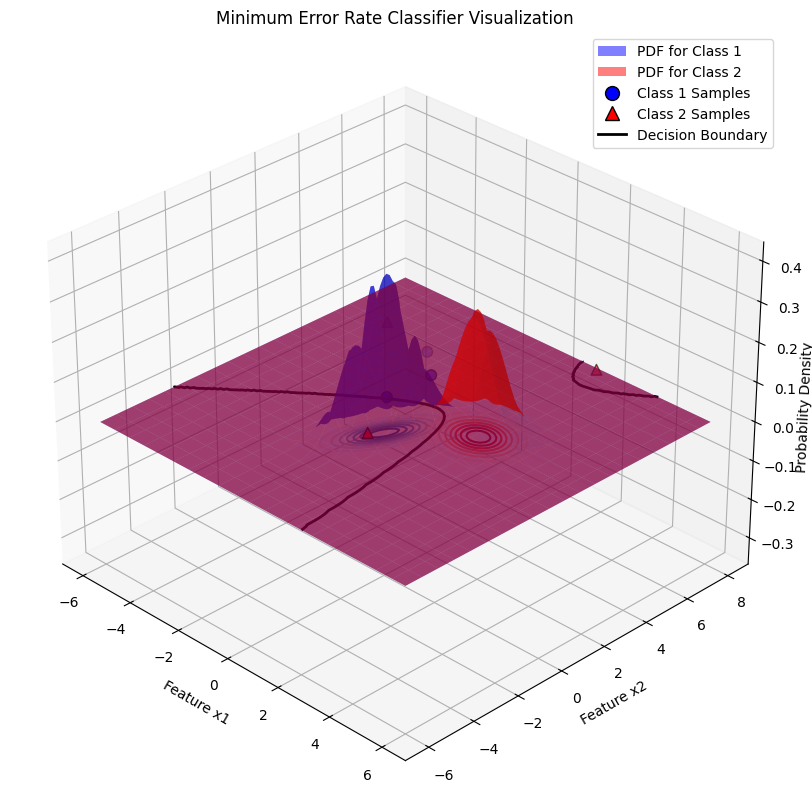

In [5]:
# 1. Create a grid of points for plotting surfaces
x_range = np.linspace(-6, 6, 100)
y_range = np.linspace(-6, 8, 100)
X, Y = np.meshgrid(x_range, y_range)
pos = np.dstack((X, Y)) # Shape (100, 100, 2)

# 2. Calculate PDF values for each point on the grid for both classes
Z1 = multivariate_normal_pdf(pos, mu1, sigma1)
Z2 = multivariate_normal_pdf(pos, mu2, sigma2)

# 3. Create the 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the 3D surfaces for the PDFs
ax.plot_surface(X, Y, Z1, color='blue', alpha=0.5, rstride=5, cstride=5, label='P(x|w1)')
ax.plot_surface(X, Y, Z2, color='red', alpha=0.5, rstride=5, cstride=5, label='P(x|w2)')

# 5. Plot the contours on the 'floor' of the plot
z_min = 0 # We can set a small negative value to avoid overlap with axis
ax.contour(X, Y, Z1, zdir='z', offset=z_min, cmap='Blues')
ax.contour(X, Y, Z2, zdir='z', offset=z_min, cmap='Reds')

# 6. Plot the decision boundary
# The boundary is where P(x|w1)P(w1) = P(x|w2)P(w2)
# Since priors are equal, this is where P(x|w1) = P(x|w2)
ax.contour(X, Y, Z1 - Z2, levels=[0], zdir='z', offset=z_min, colors='black', linewidths=2)

# 7. Plot the classified sample points
# A plane is created at a certain height to make the points clearly visible
plane_z = 0.15
if class1_points.size > 0:
    ax.scatter(class1_points[:, 0], class1_points[:, 1], plane_z, c='blue', marker='o', s=60, edgecolor='black', label='Class 1 Samples')
if class2_points.size > 0:
    ax.scatter(class2_points[:, 0], class2_points[:, 1], plane_z, c='red', marker='^', s=60, edgecolor='black', label='Class 2 Samples')

# Create a proxy artist for the legend of surfaces
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', alpha=0.5, label='PDF for Class 1'),
    Patch(facecolor='red', alpha=0.5, label='PDF for Class 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markeredgecolor='black', markersize=10, label='Class 1 Samples'),
    plt.Line2D([0], [0], marker='^', color='w', markerfacecolor='red', markeredgecolor='black', markersize=10, label='Class 2 Samples'),
    plt.Line2D([0], [0], color='black', lw=2, label='Decision Boundary')
]
ax.legend(handles=legend_elements)

# 8. Set labels and title
ax.set_xlabel('Feature x1')
ax.set_ylabel('Feature x2')
ax.set_zlabel('Probability Density', labelpad = -0.7)
ax.set_title('Minimum Error Rate Classifier Visualization')
ax.view_init(elev=30, azim=-45) # Adjust viewing angle
plt.show()